# Chapter 8 — Feature Importance

*AFML (López de Prado) snippets 8.2–8.10, on the book's synthetic dataset.*

> **Run this under the `mlfinlab` kernel (Python 3.10.20 / sklearn 1.2.2).**
> The bagging classifier uses `max_samples=1.` as a **float**. On sklearn 1.2.2
> a float `max_samples` is a fraction of the fold's *row count*. Newer sklearn
> reinterprets it as a fraction of the *summed sample weight*, and because
> `getTestData` sets `w = 1/n` (weights sum to 1) that collapses every tree to
> a single bootstrap row — importances go to noise, `oob ≈ 0.5`. See the
> LOAD-BEARING note in `feature_importance.py`.

## Why this chapter exists

Chapter 7 gave us an *honest way to score* a model (purged, embargoed CV).
Chapter 8 asks the next question: **which features actually matter?**

The hard part is that there's normally no ground truth to check an importance
method against. The book's trick is to **manufacture a dataset whose answer key
is known** (`getTestData`, snippet 8.7):

- **`I_*` — informative:** genuinely carry signal about the label.
- **`R_*` — redundant:** linear combinations of the informative features. They
  correlate with signal, so they *look* important, but carry **no new
  information**. These exist to demonstrate the **substitution effect**.
- **`N_*` — noise:** pure random. A good method should rank these near zero.

We then run four methods and grade them by feature name.

| Method | In/Out of sample | Substitution effect? | Blind spot |
|---|---|---|---|
| **MDI** (8.2) | in-sample, tree impurity | suffers it | noise never scores 0 |
| **MDA** (8.3) | out-of-sample, permutation + purged CV | suffers it | needs a scoring loop |
| **SFI** (8.4) | out-of-sample, one feature alone | **immune** | blind to *joint* effects |
| **Orthogonal/PCA** (8.5–8.6) | decorrelate first | sidesteps it | interpretation |


## Setup

The cross-chapter import reuses this repo's Chapter 7 `PurgedKFold` / `cvScore`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AFML_ROOT = r'C:\ws\AFML'   # <-- EDIT THIS to your repo root
import sys
if AFML_ROOT not in sys.path:
    sys.path.insert(0, AFML_ROOT)

from ch08.feature_importance.feature_importance import (
    getTestData, featImportance, orthoFeats, get_eVec,
    featPCA_rank_corr, plotFeatImportance,
)

np.random.seed(0)
pd.set_option('display.float_format', lambda x: f'{x:0.4f}')

## 1. The synthetic dataset (snippet 8.7)

`make_classification(shuffle=False)` lays features out in a known order —
informative, then redundant, then noise — so the positional `I_/R_/N_` naming
is a true answer key. Each label's `t1` is its own timestamp, so synthetic
labels **don't overlap** (purging barely bites here — that's deliberate, it
isolates the substitution-effect lesson from the purging lesson).

In [2]:
trnsX, cont = getTestData(n_features=40, n_informative=10,
                          n_redundant=10, n_samples=10000)
print('trnsX:', trnsX.shape, '| bin balance:', cont['bin'].value_counts().to_dict())
print('feature types:', {k: sum(c[0]==k for c in trnsX.columns) for k in 'IRN'})
trnsX.iloc[:3, [0,1,10,11,20,21]]

trnsX: (10000, 40) | bin balance: {0: 5001, 1: 4999}
feature types: {'I': 10, 'R': 10, 'N': 20}


,I_0,I_1,R_0,R_1,N_0,N_1
1988-03-09 12:27:14.768347,2.8437,0.4566,5.1561,1.7858,0.3047,-2.0096
1988-03-10 12:27:14.768347,3.5615,-1.5661,-0.1515,-1.7257,0.5623,-1.1053
1988-03-11 12:27:14.768347,7.6992,-3.0301,2.8046,5.5263,-2.6066,-0.8216


### The substitution effect, made visible

A correlation heatmap shows *why* redundant features will steal importance:
each `R_*` is a linear combination of the informative features, so the I–R
block lights up. A model can split on an informative feature **or** its
redundant twin — importance gets shared between them.

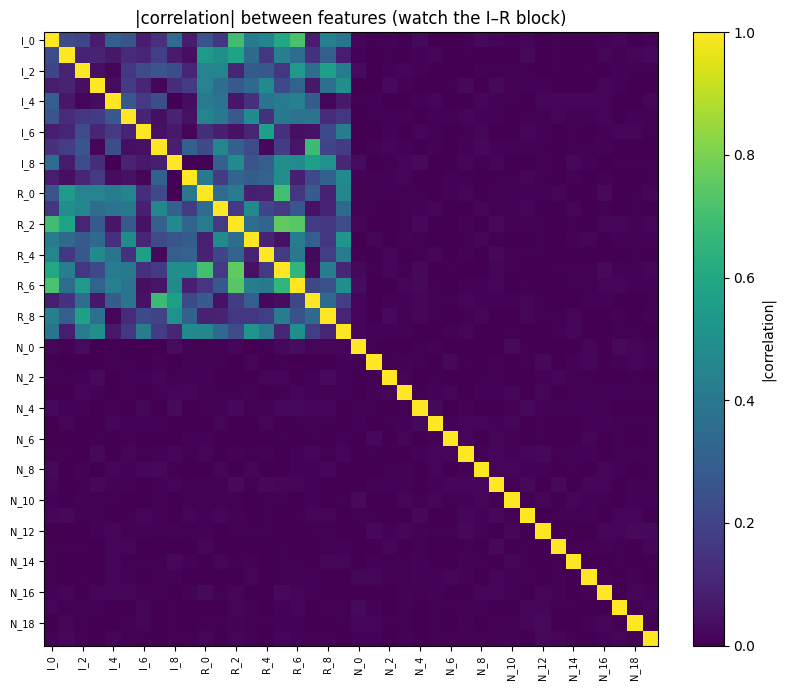

In [3]:
corr = trnsX.corr().abs()
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr.values, cmap='viridis', vmin=0, vmax=1)
ax.set_xticks(range(0, 40, 2)); ax.set_xticklabels(trnsX.columns[::2], rotation=90, fontsize=7)
ax.set_yticks(range(0, 40, 2)); ax.set_yticklabels(trnsX.columns[::2], fontsize=7)
fig.colorbar(im, ax=ax, fraction=0.046, label='|correlation|')
ax.set_title('|correlation| between features (watch the I–R block)')
plt.tight_layout(); plt.show()

## 2. MDI — Mean Decrease Impurity (snippet 8.2)

**In-sample.** Read straight off the fitted forest: how much each feature
reduced impurity at its splits, averaged over trees. Two things to watch:

1. **Noise never scores zero.** In-sample, a random feature always finds *some*
   spurious impurity reduction — expect `N_*` at roughly *half* an informative
   feature, not zero. (This is exactly why MDA exists.)
2. **`max_features=1`** on the trees forces each split onto a single random
   feature (the "anti-masking" trick). A tree that never split on a feature
   reports 0 for it; `featImpMDI` sets those structural zeros to NaN so the
   mean reflects trees that *used* the feature.

The dotted red line marks `1/n_features` — the "uniform importance" reference.

oob=0.9232   oos=0.8304
mean importance by type I/R/N: {'I': 0.0326, 'R': 0.0337, 'N': 0.0168}


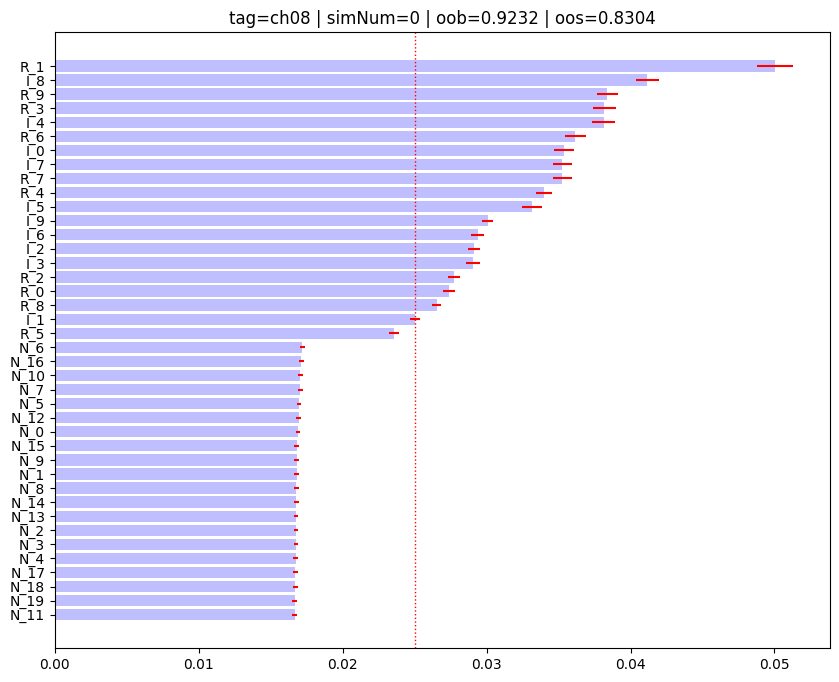

In [4]:
imp_mdi, oob_mdi, oos_mdi = featImportance(
    trnsX, cont, n_estimators=400, cv=10, scoring='accuracy', method='MDI', n_jobs=4)
print(f'oob={oob_mdi:.4f}   oos={oos_mdi:.4f}')

def by_type(imp):
    # MEAN per-feature importance within each type -- not a summed share.
    # There are 20 N features vs 10 I/10 R, so summing shares makes noise look
    # big by count; and for SFI (accuracy levels, not decrements) the share is
    # outright misleading. The within-type mean is the honest comparison.
    d = imp[['mean']].copy(); d['type'] = [i[0] for i in d.index]
    return d.groupby('type')['mean'].mean().reindex(['I','R','N'])
print('mean importance by type I/R/N:', by_type(imp_mdi).round(4).to_dict())

ax = plotFeatImportance(imp_mdi, oob=oob_mdi, oos=oos_mdi, method='MDI', tag='ch08')
plt.show()

## 3. MDA — Mean Decrease Accuracy (snippet 8.3)

**Out-of-sample.** Fit on each **purged-CV** train fold, score the test fold,
then re-score with one feature's column **permuted**. The drop is that feature's
importance. This is where Chapter 7's `PurgedKFold` gets consumed.

Two things to note:

1. **The permutation bug we fixed.** The book writes
   `np.random.shuffle(X1_[j].values)`, which is a *silent no-op* on pandas 1.5.3
   (`.values` can be a copy) and a hard error on pandas ≥2.0 — either way MDA
   would report ~zero importance for everything. We reassign a permutation
   instead: `X1_[j] = np.random.permutation(X1_[j].values)`.
2. **MDA pushes noise to ≈0** (its advantage over MDI) — but it **still suffers
   the substitution effect**: permuting a redundant feature barely hurts
   accuracy because the model leans on its informative twin, so `R_*` can look
   *as unimportant as noise*, even slightly negative.

oob=0.9232   oos=0.8296
mean importance by type I/R/N: {'I': 0.0783, 'R': 0.0521, 'N': 0.0005}


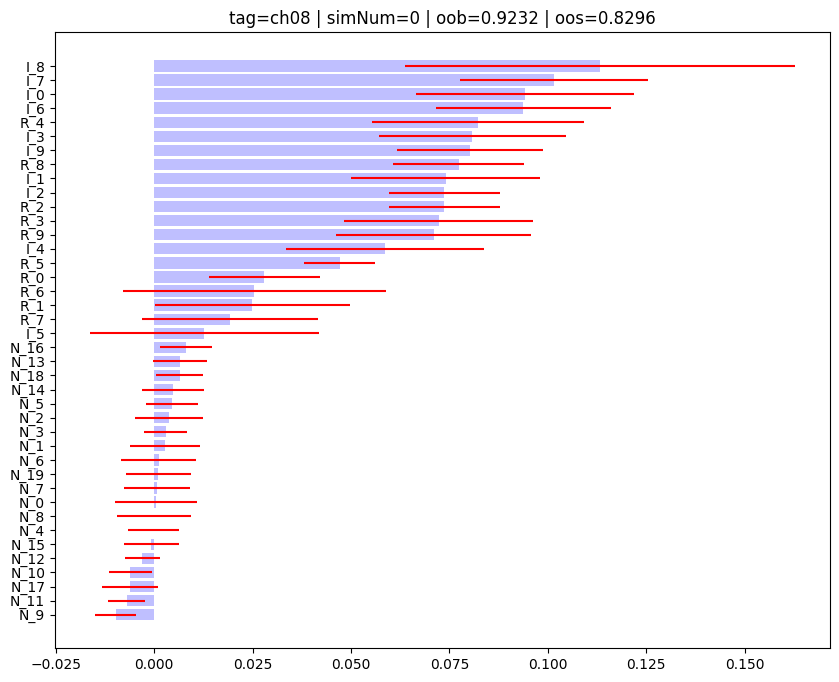

In [5]:
np.random.seed(0)
imp_mda, oob_mda, oos_mda = featImportance(
    trnsX, cont, n_estimators=400, cv=10, scoring='accuracy', method='MDA', n_jobs=4)
print(f'oob={oob_mda:.4f}   oos={oos_mda:.4f}')
print('mean importance by type I/R/N:', by_type(imp_mda).round(4).to_dict())

ax = plotFeatImportance(imp_mda, oob=oob_mda, oos=oos_mda, method='MDA', tag='ch08')
plt.show()

## 4. SFI — Single Feature Importance (snippet 8.4)

**Out-of-sample, one feature at a time.** Score each feature *alone* via purged
CV. Because features are scored in isolation, correlated features can't dilute
each other — SFI is **immune to substitution effects**. Its blind spot is the
mirror image: it can't see **joint** effects (a pair of features that only
predict well together).

On this dataset a single feature is only weakly predictive, so SFI scores hover
near the 0.5 base rate; the informative features still edge out noise, but the
separation is subtler than MDA's.

oob=0.9050   oos=0.6374
mean importance by type I/R/N: {'I': 0.4331, 'R': 0.4514, 'N': 0.4367}


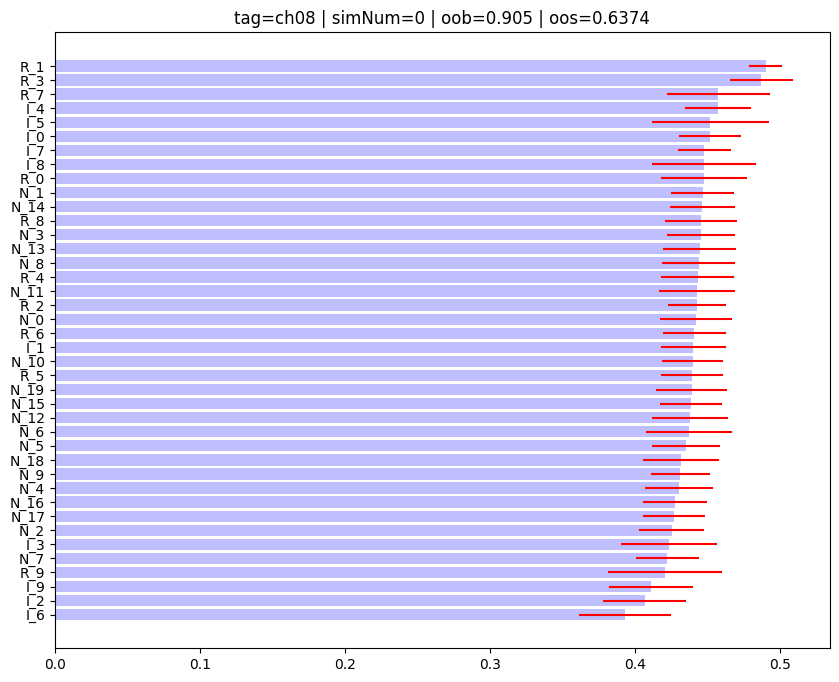

In [6]:
imp_sfi, oob_sfi, oos_sfi = featImportance(
    trnsX, cont, n_estimators=100, cv=5, scoring='accuracy', method='SFI', n_jobs=4)  # lighter: single-column fits, 40-way slow path
print(f'oob={oob_sfi:.4f}   oos={oos_sfi:.4f}')
print('mean importance by type I/R/N:', by_type(imp_sfi).round(4).to_dict())

ax = plotFeatImportance(imp_sfi, oob=oob_sfi, oos=oos_sfi, method='SFI', tag='ch08')
plt.show()

## 5. Side by side — the money plot

**Mean** per-feature importance by type, per method (mean, not summed share:
there are twice as many N features, so summing would let noise "win" on count
alone). Read *within* each method — the scales differ:

- **MDI**: noise sits around half of signal — nonzero, its in-sample bias.
- **MDA**: noise collapses toward zero while informative dominates — the payoff.
- **SFI**: roughly flat across I/R/N. That's not a bug: `make_classification`'s
  informative features are only *jointly* predictive, so no single feature
  stands out when scored alone — SFI's blind spot to joint effects, in action.

type,I,R,N
MDI,0.0326,0.0337,0.0168
MDA,0.0783,0.0521,0.0005
SFI,0.4331,0.4514,0.4367


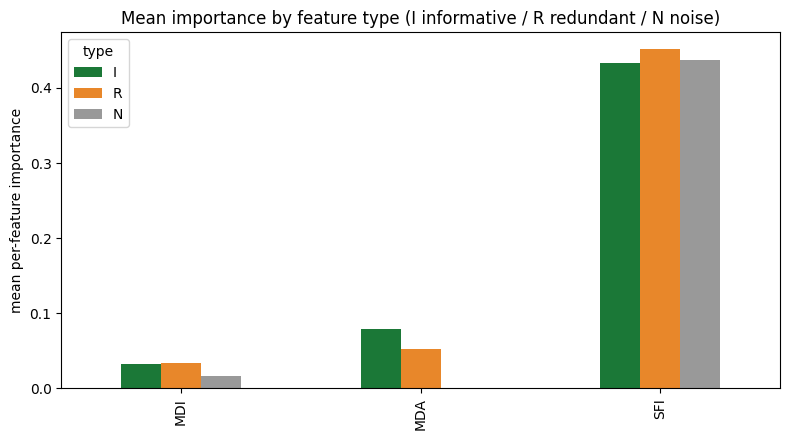

In [7]:
summary = pd.DataFrame({'MDI': by_type(imp_mdi),
                        'MDA': by_type(imp_mda),
                        'SFI': by_type(imp_sfi)}).T
display(summary.round(4))

ax = summary.plot(kind='bar', figsize=(8,4.5),
                  color={'I':'#1b7837','R':'#e8872a','N':'#999999'})
ax.set_ylabel('mean per-feature importance')
ax.set_title('Mean importance by feature type (I informative / R redundant / N noise)')
ax.legend(title='type'); plt.tight_layout(); plt.show()

## 6. Orthogonal features + weighted Kendall's τ (snippets 8.5–8.6)

PCA is **unsupervised** — it never sees the labels. The book's corroboration:
transform the features into orthogonal principal components, run the same cheap
MDI *on the PCs*, then correlate each PC's importance with its **eigenvalue rank**
(PC_1 = highest variance) via a weighted Kendall's τ. A **positive** τ means the
model finds the high-variance directions important — evidence the importance
reflects real structure, not noise.

First the book's toy (8.6) exactly, then the real computation on the PCs.

book 8.6 toy  weightedtau = 0.8133
kept 28 of 40 PCs for 95% variance
weighted Kendall tau (PC importance vs eigenvalue rank) = 0.4350
positive => high-variance PCs are the important ones = real structure


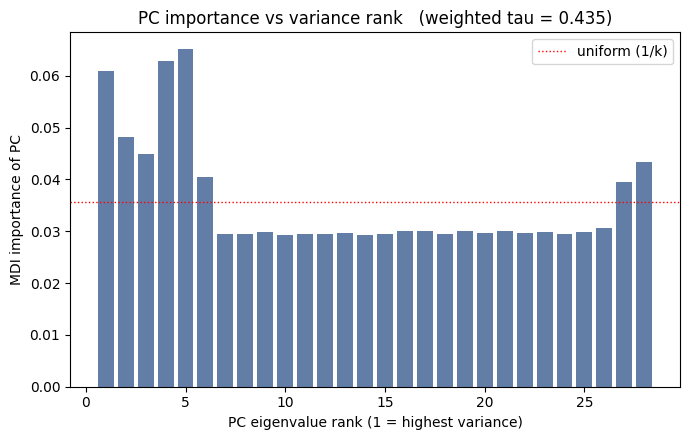

In [8]:
from feature_importance import featImpMDI
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

# Book's toy (snippet 8.6), reproduced exactly:
tau_toy = featPCA_rank_corr(np.array([.55,.33,.07,.05]), np.array([1,2,4,3]))
print('book 8.6 toy  weightedtau =', round(tau_toy, 4))

# Real: importance ON the orthogonal PCs, correlated with eigenvalue rank.
dfP = orthoFeats(trnsX, varThres=.95)
dfP = pd.DataFrame(dfP, index=trnsX.index,
                   columns=['PC_%d' % (i+1) for i in range(dfP.shape[1])])
print(f'kept {dfP.shape[1]} of {trnsX.shape[1]} PCs for 95% variance')

pc_clf = DecisionTreeClassifier(criterion='entropy', max_features=1,
                                class_weight='balanced')
pc_bag = BaggingClassifier(estimator=pc_clf, n_estimators=400, max_features=1.,
                           max_samples=1., oob_score=True, n_jobs=4)
pc_fit = pc_bag.fit(dfP, cont['bin'], sample_weight=cont['w'].values)
pc_imp = featImpMDI(pc_fit, featNames=dfP.columns)['mean']
pc_rank = np.arange(1, len(pc_imp)+1)          # PCs already eigenvalue-ordered
tau = featPCA_rank_corr(pc_imp.values, pc_rank)
print(f'weighted Kendall tau (PC importance vs eigenvalue rank) = {tau:.4f}')
print('positive => high-variance PCs are the important ones = real structure')

fig, ax = plt.subplots(figsize=(7,4.5))
ax.bar(pc_rank, pc_imp.values, color='#1f4880', alpha=.7)
ax.axhline(1./len(pc_imp), color='r', ls='dotted', lw=1, label='uniform (1/k)')
ax.set_xlabel('PC eigenvalue rank (1 = highest variance)')
ax.set_ylabel('MDI importance of PC')
ax.set_title(f'PC importance vs variance rank   (weighted tau = {tau:.3f})')
ax.legend(); plt.tight_layout(); plt.show()

## Takeaways

- **MDI** is cheap but in-sample: noise never reaches zero, and it suffers
  substitution effects. Good for a first look, not for decisions.
- **MDA** pushes noise to ≈0 (honest, out-of-sample) but still shares importance
  across correlated features — redundant features can masquerade as noise.
- **SFI** is immune to substitution effects but blind to joint effects.
- **Orthogonal features + weighted τ** give an unsupervised sanity check on the
  supervised ranking.

**On our real BTC pipeline:** the training table currently has a *single*
feature (`fracdiff`), which makes feature importance degenerate — that's why we
demonstrated on the book's synthetic data. A natural next step is to enrich the
real table (multiple frac-diff `d` values, a volatility feature, etc.) so these
methods say something meaningful there too.

*Next: Chapter 9 — Hyper-Parameter Tuning with Cross-Validation, which reuses
the same purged-CV machinery.*

---
### TDD results (`test_feature_importance.py`)

Embedded per project convention. **Sandbox run** (Python 3.12.3 / sklearn 1.8.0);
re-run under `mlfinlab` (3.10.20 / 1.2.2) for the canonical header — there the
`max_samples` float warning does not appear.

```
============================= test session starts ==============================
collected 17 items

test_gettestdata_shapes_and_columns PASSED                              [  5%]
test_gettestdata_column_order_is_I_then_R_then_N PASSED                 [ 11%]
test_gettestdata_weights_and_t1 PASSED                                  [ 17%]
test_mdi_normalizes_and_covers_all_features PASSED                      [ 23%]
test_mdi_informative_beats_noise PASSED                                 [ 29%]
test_permutation_idiom_actually_shuffles PASSED                         [ 35%]
test_mda_noise_near_zero_informative_positive PASSED                    [ 41%]
test_mda_rejects_bad_scoring PASSED                                     [ 47%]
test_sfi_returns_per_feature_mean_std PASSED                            [ 52%]
test_orthofeats_shape_and_decorrelation PASSED                          [ 58%]
test_get_evec_threshold_reduces_dimension PASSED                        [ 64%]
test_featpca_rank_corr_matches_book_example PASSED                      [ 70%]
test_featimportance_returns_triplet[MDI] PASSED                         [ 76%]
test_featimportance_returns_triplet[MDA] PASSED                         [ 82%]
test_featimportance_returns_triplet[SFI] PASSED                         [ 88%]
test_featimportance_rejects_bad_method PASSED                           [ 94%]
test_testfunc_summary_table PASSED                                      [100%]

======================= 17 passed, 42 warnings in 32.48s =======================
```